# 23_01 상태 변화 추적 

In [20]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


## 실습 1. 데이터 불러오기와 단일 설비 센서 그리기

### 목표
데이터를 불러와 구조를 확인하고 엔진 한 대를 골라 센서를 시간순으로 그리기

### 단계
- 파일을 불러와 크기와 엔진 목록 확인
- 2번 엔진만 골라 회차 순으로 정렬
- 센서 하나를 시간순 선 그래프로 그리기

### 예상 결과
전체 1036행·엔진 5대, 2번 엔진 287행; 센서 곡선이 그려짐

   설비번호  시퀀스  컨베이어전류   회전A전류   회전B전류  펌프A전류  펌프B전류
0     2    1     0.0  0.0496  0.7037    0.0    0.0
1     2    2     0.0  0.0496  0.7037    0.0    0.0
2     2    3     0.0  0.0496  0.7037    0.0    0.0


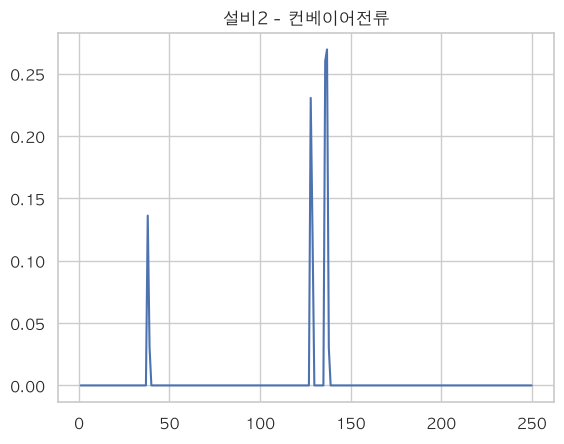

In [21]:
# 실습 1 코드

df = pd.read_csv("data/23_전기Panel.csv", encoding="UTF-8")

unit2 = df[df["설비번호"] == 2].copy().sort_values("시퀀스").reset_index(drop=True)

print(unit2.head(3))

plt.plot(unit2["시퀀스"], unit2["컨베이어전류"])
plt.title("설비2 - 컨베이어전류")
plt.show()

## 실습 2. 단일 센서 이동평균 추적

## 목표
창 크기 10 이동평균을 구해 원본 위에 겹쳐 추세를 읽기
### 단계
- 센서에 창 크기 10 이동평균을 새 열로 담기
- 원본을 옅게, 이동평균을 진하게 겹쳐 그리기
- 이동평균선이 추세를 드러냄을 확인
### 예상 결과
들쭉날쭉한 원본 위로 매끈한 이동평균 추세선

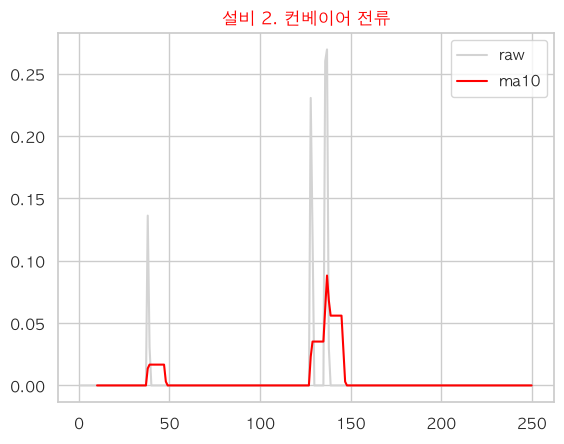

In [22]:
# 실습 2 코드

unit2["ma10"] = unit2["컨베이어전류"].rolling(window=10).mean()

unit2.tail(10)

plt.plot(unit2["시퀀스"], unit2["컨베이어전류"], color = "lightgray", label="raw" )
plt.plot(unit2["시퀀스"], unit2["ma10"], color="red", label="ma10") # 조금 더 평탄화됨

plt.legend()
plt.title("설비 2. 컨베이어 전류", color = "red")
plt.show()


## 실습 3. 창 크기 3종 비교

### 목표
창 크기를 5·10·30으로 바꿔 매끈함과 반응성의 맞교환을 비교
### 단계
- 세 가지 창 크기로 이동평균을 각각 구하기
- 세 이동평균을 한 그래프에 겹쳐 그리기
- 창이 클수록 매끄럽지만 반응이 느려짐을 확인
### 예상 결과
창이 클수록 곡선이 매끄럽고 앞쪽 빈 구간이 늘어남

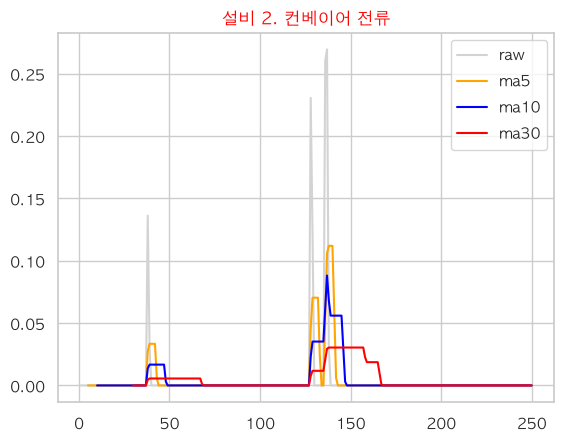

In [23]:
# 실습 3 코드

unit2["ma10"] = unit2["컨베이어전류"].rolling(window=10).mean()
unit2["ma5"] = unit2["컨베이어전류"].rolling(window=5).mean()
unit2["ma30"] = unit2["컨베이어전류"].rolling(window=30).mean()

unit2.tail(10)

plt.plot(unit2["시퀀스"], unit2["컨베이어전류"], color="lightgray", label="raw")
plt.plot(unit2["시퀀스"], unit2["ma5"], color="orange", label="ma5")  # 조금 더 평탄화됨
plt.plot(unit2["시퀀스"], unit2["ma10"], color="blue", label="ma10")
plt.plot(unit2["시퀀스"], unit2["ma30"], color="red", label="ma30") 


# window가 클수록 더욱 평탄화 됨 
plt.legend()
plt.title("설비 2. 컨베이어 전류", color="red")
plt.show()

## 실습 4. 이동평균·이동표준편차 동시 추적
### 목표
이동평균과 이동표준편차를 함께 계산해 추세와 변동성을 동시에 추적
### 단계
- 창 크기 10으로 이동평균과 이동표준편차를 구하기
- 두 통계를 위아래 두 칸으로 나눠 그리기
- 초반과 후반의 변동성 평균을 비교
### 예상 결과
후반 변동성이 초반의 약 2배(5.5 → 9.5)로 커짐

In [24]:
# 실습 4 코드

unit2["st10"] = unit2["컨베이어전류"].rolling(window=10).std()

early = unit2["st10"].iloc[10:50].mean()
late = unit2["st10"].iloc[150:].mean()

print(f"초반 변동성 : {round(early,4)}")
print(f"후반 변동성 : {round(late,4)}")

초반 변동성 : 0.011
후반 변동성 : 0.0


## 실습 5. 변화량·변화율 계산과 시각화
### 목표
변화량과 변화율로 급변을 포착하고 이동평균 후 변화량으로 잡음을 줄이기
### 단계
- 직전 대비 변화량과 변화율을 각각 구하기
- 앞부분 값을 확인해 첫 값이 비는 이유 이해
- 이동평균을 먼저 낸 뒤 변화량을 구해 잡음이 줄어듦을 확인
### 예상 결과
변화량 앞부분 -0.43·3.07…, 첫 값은 비교 대상이 없어 빈 값

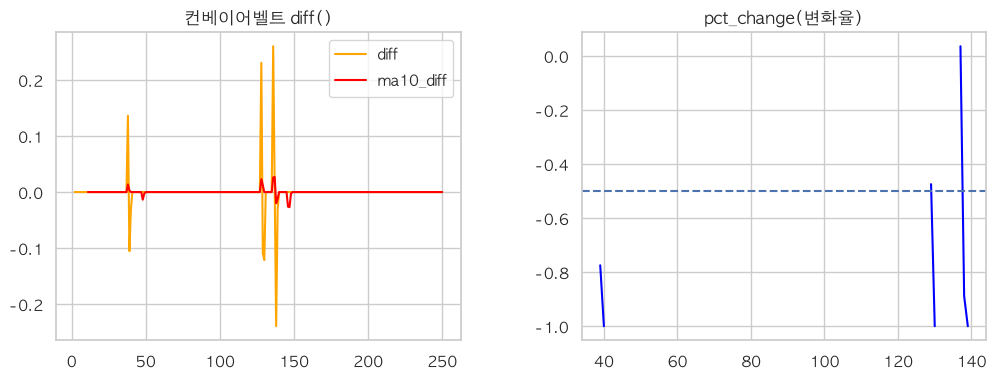

In [25]:
# 실습 5 코드

unit2["diff"] = unit2["컨베이어전류"].diff()
unit2["pct"] = unit2["컨베이어전류"].pct_change()
unit2["ma10_diff"] = unit2["ma10"].diff()

unit2.tail(20)

# 위 항목들을 그래프로
plt.figure(figsize=(12, 4))
plt.subplots_adjust(wspace=0.3, hspace=0.5)  # 간격조정


plt.subplot(1,2,1)

plt.plot(unit2["시퀀스"], unit2["diff"], color="orange", label="diff")  # 조금 더 평탄화됨
plt.plot(unit2["시퀀스"], unit2["ma10_diff"], color="red", label="ma10_diff")
plt.title("컨베이어벨트 diff()")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(unit2["시퀀스"],unit2["pct"], color="blue", label="pct")
plt.axhline(-0.5, linestyle="--")
plt.title("pct_change(변화율)")

plt.show()

## 실습 6. 단순 변화점 탐지와 구간 표시
### 목표
잔차와 임계값으로 변화점을 찾고 그래프에 세로선으로 표시
### 단계
- 원본에서 이동평균을 뺀 잔차를 구하기
- 잔차 표준편차의 두 배를 임계값으로 정해 변화점 표시
- 변화점 위치를 세로선으로 그래프에 표시
### 예상 결과
임계값 약 16.3, 변화점 13개; 대부분 후반부에 몰림

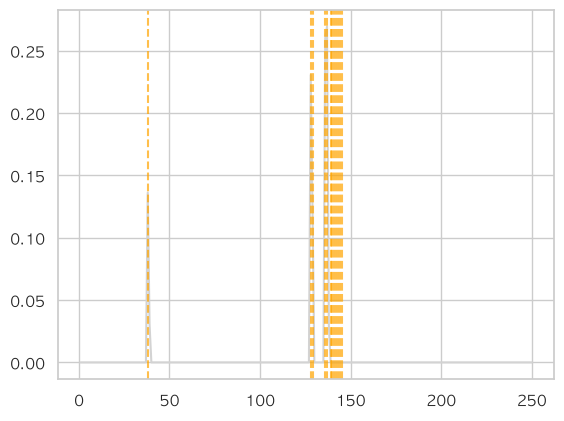

In [26]:
# 실습 6 코드

roli = unit2["컨베이어전류"].rolling(10).mean()
resid = unit2["컨베이어전류"] - roli

# 잔차 표준편차의 두배를 임계값으로 정함 
thr = 2 * resid.std()

# 변화점찾기 
unit2["is_change"] = resid.abs() > thr 

plt.plot(unit2["시퀀스"], unit2["컨베이어전류"], color="lightgray")

for c in unit2.loc[unit2["is_change"], "시퀀스"]:
    plt.axvline(c, color="orange", linestyle = '--', alpha=0.7)

plt.show()

## 실습 7. window·기준값 바꿔 결과 비교
### 목표
창 크기와 임계 배수를 바꿔 변화점 개수가 어떻게 달라지는지 비교
### 단계
· 잔차 기반 변화점 개수를 세는 함수를 만들기
· 창 크기를 바꿔 가며 변화점 개수 비교
· 임계 배수를 바꿔 가며 변화점 개수 비교
### 예상 결과
창이 커지거나 배수가 작아질수록 변화점 개수가 달라짐

In [27]:
# 실습 7 코드

series = unit2["컨베이어전류"]

k =2 

for window in [5,10,20] :
    r = series - series.rolling(window).mean()
    print("window :", window, int((r.abs() > k * r.std()).sum()))


window = 10 

for k in [1.5, 2.0, 3.0] :
    r = series - series.rolling(window).mean()
    print("k :", k, int((r.abs() > k*r.std()).sum()))

window : 5 11
window : 10 12
window : 20 5
k : 1.5 12
k : 2.0 12
k : 3.0 5


## 실습 8. 단일 설비 상태 추적 미니 통합
### 목표
이동통계·변화점·변동성을 한데 모아 한 엔진의 상태를 요약
### 단계
- 이동평균·이동표준편차·변화점을 한 번에 계산
- 초반·후반 변동성과 변화점 개수를 요약
- 후반 변화점 비율로 상태를 한 문장으로 진단
### 예상 결과
후반 변동성이 커지고 변화점 13개, 후반 비율이 높아 열화 진행

In [30]:
# 실습 8 코드

series = unit2["컨베이어전류"]
window = 10

unit2["ma"] = series.rolling(window).mean() # 이동평균
unit2["std"] = series.rolling(window).std() # 이동표준편차

resid = series - unit2["ma"]
thr = 2 * resid.std() # 잔차 표준편차의 두배를 임계값으로 정함

unit2["chg"] = resid.abs() > thr # 변화점을 찾기 
half = unit2["시퀀스"].median()

print("전반부 변동성")
print("이동표준편차 :", round(unit2["std"].iloc[10:50].mean(), 4))
print("후반부 변동성")
print("이동표준편차 :", round(unit2["std"].iloc[150:].mean(), 4))

print("-"*30)
print("변화점 : ", int(unit2["chg"].sum()))
print("후반 비율 : ", round(unit2.loc[unit2["시퀀스"]>half, "chg"].mean(),2))

전반부 변동성
이동표준편차 : 0.011
후반부 변동성
이동표준편차 : 0.0
------------------------------
변화점 :  12
후반 비율 :  0.09


# 23_02 다중센서 패턴 분석

In [ ]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


## 실습 1. 시간 인덱싱과 슬라이싱
### 목표
글자 날짜를 시간 형식으로 바꿔 인덱스로 올리고 날짜로 구간 자르기
### 단계
- 시각 열의 자료형을 확인하고 시간 형식으로 변환
- 시간 열을 인덱스로 올리기
- 하루·기간을 날짜로 잘라 행 수 확인
### 예상 결과
자료형이 시간으로 바뀌고, 하루 24행·사흘 72행

In [ ]:
# 실습 1 코드

TS = "data/23_cmapss_unit1_timestamp.csv"

ts = pd.read_csv(TS, encoding="UTF-8")
ts["timestamp"] = pd.to_datetime(ts["timestamp"])
ts = ts.set_index("timestamp")

print(len(ts.loc["2024-01-02"]))

24


## 실습 2. 리샘플링 집계와 시간 이동통계
### 목표
시간 단위로 리샘플링해 대표값을 구하고 일별 이동평균으로 추세를 보기
### 단계
- 하루 단위 평균과 6시간 단위 평균을 각각 구하기
- 각 결과의 개수로 단위 차이를 확인
- 일별 평균에 이동평균을 걸어 추세를 매끄럽게
### 예상 결과
하루 평균 8개·6시간 평균 32개, 일별 값이 상승 추세

In [ ]:
# 실습 2 코드

daily = ts["sensor_3"].resample("1D").mean()
print("하루단위 평균 : ", daily.round(2).head())
sixhours = ts["sensor_3"].resample("6h").mean()
print("6h단위 평균 : ", sixhours.round(2).head())

daily_ma = daily.rolling(3).mean()
print('일별 평균의 이동평균 계산: ', daily_ma)

하루단위 평균 :  timestamp
2024-01-01    1592.12
2024-01-02    1590.92
2024-01-03    1593.35
2024-01-04    1597.82
2024-01-05    1603.70
Freq: D, Name: sensor_3, dtype: float64
6h단위 평균 :  timestamp
2024-01-01 00:00:00    1588.81
2024-01-01 06:00:00    1592.07
2024-01-01 12:00:00    1593.34
2024-01-01 18:00:00    1594.26
2024-01-02 00:00:00    1589.86
Freq: 6h, Name: sensor_3, dtype: float64
일별 평균의 이동평균 계산:  timestamp
2024-01-01            NaN
2024-01-02            NaN
2024-01-03    1592.129722
2024-01-04    1594.028889
2024-01-05    1598.290833
2024-01-06    1604.036111
2024-01-07    1609.458611
2024-01-08    1617.726528
Freq: D, Name: sensor_3, dtype: float64


## 실습 3. 다중센서 정규화와 겹쳐 비교
### 목표
여러 센서를 0~1로 정규화해 같은 눈금에서 함께 비교
### 단계
· 세 센서를 최소·최대 기준으로 0~1로 정규화
· 정규화 후 최솟값·최댓값이 0과 1인지 확인
· 이동평균을 걸어 겹쳐 그릴 준비
### 예상 결과
각 센서의 최솟값 0·최댓값 1로 눈금이 맞춰짐

In [ ]:
# 실습 3 코드

df = pd.read_csv("data/23_cmapss_fd001_sample.csv")

u2 = df[df["unit_number"] == 2].copy().reset_index(drop=True)
# u2.head()

# 정규화 
cols = ["sensor_2","sensor_7", "sensor_11"]
norm = (u2[cols] - u2[cols].min()) / (u2[cols].max() - u2[cols].min())
print(norm.describe())

norm_ma = norm.rolling(window=10).mean()
print(norm_ma.tail())

         sensor_2    sensor_7   sensor_11
count  287.000000  287.000000  287.000000
mean     0.334037    0.664256    0.269113
std      0.245549    0.220993    0.170577
min      0.000000    0.000000    0.000000
25%      0.120705    0.520908    0.145794
50%      0.267841    0.722820    0.224299
75%      0.499119    0.854839    0.351402
max      1.000000    1.000000    1.000000
     sensor_2  sensor_7  sensor_11
282  0.810044  0.265352   0.669533
283  0.834185  0.256870   0.697009
284  0.820176  0.272103   0.675140
285  0.849604  0.282139   0.685981
286  0.861498  0.241995   0.636822


## 실습 4. 다중센서 변화 폭 비교
### 목표
정규화한 여러 센서의 초반·후반 값을 비교해 변화 폭이 큰 센서를 찾기
### 단계
- 여섯 센서를 정규화하고 이동평균을 걸기
- 각 센서의 초반과 후반 평균을 구하기
- 초반·후반 차이로 변화 폭이 큰 감시 센서 선별
### 예상 결과
sensor_2는 크게 상승, sensor_7은 하락 — 변화 폭 큰 센서 부각

In [ ]:
# 실습 4 코드

sensors = ["sensor_2",	"sensor_3",	"sensor_4",	"sensor_7",	"sensor_11"]

n6 = (u2[sensors] - u2[sensors].min()) / (u2[sensors].max() - u2[sensors].min())

n6ma = n6.rolling(window=10).mean()

for c in ["sensor_2","sensor_7", "sensor_11"] :
    early = n6ma[c].iloc[10:40].mean()
    last = n6ma[c].iloc[150:].mean()
    print(c, round(early, 2), round(last,2), round(last-early, 2))

sensor_2 0.07 0.53 0.46
sensor_7 0.9 0.49 -0.41
sensor_11 0.13 0.39 0.26


## 실습 5. 다중센서 상관 heatmap
### 목표
여러 센서의 상관행렬을 구해 heatmap으로 함께 움직이는 센서를 파악
### 단계
- 여섯 센서의 상관행렬을 계산
- 히트맵으로 색과 숫자를 함께 표시
- 진한 칸으로 강한 양·음 관계를 읽기
### 예상 결과
sensor_2와 sensor_7이 강한 음(-0.96), sensor_2와 sensor_11이 양(0.84)


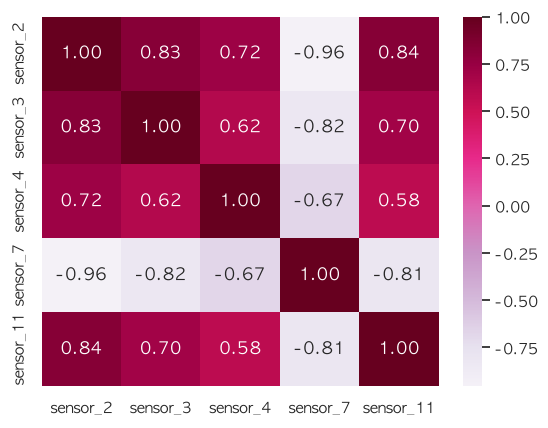

In [ ]:
# 실습 5 코드

corr = u2[sensors].corr()
corr.head()

sns.heatmap(corr, cmap="PuRd", center=0, annot=True, fmt="0.2f")
plt.show()

## 실습 6. 상관 높은 센서쌍 추출
### 목표
상관행렬에서 대각선을 빼고 가장 강한 음·양의 센서쌍을 추출
### 단계
- 상관행렬에서 자기 자신 대각선을 제외
- 센서쌍을 상관값 순으로 정렬
- 가장 강한 음의 쌍과 양의 쌍을 확인
### 예상 결과
음의 최강쌍 sensor_2·sensor_7(-0.955), 양의 최강쌍 sensor_2·sensor_11(0.839)

In [ ]:
# 실습 6 코드

## 실습 7. 종합 통합 분석
### 목표
이동통계·변화점을 계산하고 구간별로 나눠 이상 의심 구간을 도출
### 단계
- 이동평균·이동표준편차·변화점을 한 번에 계산
- 초반·후반 변동성과 변화점 개수를 요약
- 회차 구간별 변동성·변화점으로 이상 의심 구간 찾기
### 예상 결과
후반 변동성이 커지고 변화점 19개, 216~288 구간에 집중

In [ ]:
s = u2["sensor_2"]

u2["ma"] = s.rolling(10).mean()
u2["std"] = s.rolling(10).std()

resid = s - u2["ma"]
u2["chg"] = resid.abs() > 2 * resid.std()

print("변동성 초반 : ", round(u2["std"].iloc[10:50].mean(), 3))
print("변동성 후반 : ", round(u2["std"].iloc[150:].mean(), 3))

print("변화점", int(u2["chg"].sum()))

for lo, hi in ((0,72), (72,144), (144,216), (216, 288)):
    seg = u2[(u2.time_cycles > lo) & (u2.time_cycles <= hi)]
    print(f"{lo} ~ {hi}: 변동성 {seg["std"].mean():.3f},  변화점 {int(seg["chg"].sum())}개")

변동성 초반 :  0.319
변동성 후반 :  0.516
변화점 19
0 ~ 72: 변동성 0.304,  변화점 0개
72 ~ 144: 변동성 0.311,  변화점 1개
144 ~ 216: 변동성 0.295,  변화점 0개
216 ~ 288: 변동성 0.723,  변화점 18개


In [ ]:
c

'sensor_11'